In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR, SVC
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report, accuracy_score

# Load dataset
file_path = "product_monthly_panel.csv"
df = pd.read_csv(file_path)

# Print column names to verify correct target selection
print("Columns in dataset:", df.columns)

# Handle missing values in 'is_recommended' before converting to int
df['is_recommended'] = df['is_recommended'].fillna(0).astype(int)

# Convert categorical columns to numerical format using LabelEncoder
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Define correct target variables
regression_target = 'rating'  # Predicting product rating
classification_target = 'is_recommended'  # Predicting recommendation likelihood

# Ensure the target columns exist
if regression_target not in df.columns or classification_target not in df.columns:
    raise KeyError(f"One or both target columns '{regression_target}' and '{classification_target}' do not exist!")

# Drop missing values to prevent issues
df.dropna(inplace=True)


Columns in dataset: Index(['product_id', 'submission_time', 'rating', 'is_recommended',
       'helpfulness', 'total_feedback_count', 'total_neg_feedback_count',
       'total_pos_feedback_count', 'price_usd', 'brand_name', 'skin_tone',
       'eye_color', 'skin_type', 'hair_color'],
      dtype='object')


In [ ]:
# SVM Regression Task
# -----------------------------

# Select numerical features for regression (excluding target)
regression_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
regression_features.remove(regression_target)

X_reg = df[regression_features]
y_reg = df[regression_target]

In [ ]:
# Split data
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


In [ ]:
# Standardize features
scaler_reg = StandardScaler()
X_reg_train = scaler_reg.fit_transform(X_reg_train)
X_reg_test = scaler_reg.transform(X_reg_test)

In [ ]:
# Ensure y_reg_train is a 1D array
y_reg_train = np.ravel(y_reg_train)

# Use a simpler SVR model with fewer computations
svr = SVR(kernel='linear', C=1, epsilon=0.1, max_iter=1000)  # Limit iterations to speed up training
try:
    print("Fitting SVR model...")
    svr.fit(X_reg_train, y_reg_train)
    print("SVR model training completed.")
    y_reg_pred = svr.predict(X_reg_test)
    mse = mean_squared_error(y_reg_test, y_reg_pred)
    r2 = r2_score(y_reg_test, y_reg_pred)
    print("SVR Regression Mean Squared Error:", mse)
    print("SVR Regression R2 Score:", r2)
except Exception as e:
    print("SVR model failed to run:", str(e))

Fitting SVR model...


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVR model training completed.
SVR Regression Mean Squared Error: 3.699237536014152
SVR Regression R2 Score: -3.1260174249012653


In [ ]:
# Evaluate SVR model
y_reg_pred = svr.predict(X_reg_test)
mse = mean_squared_error(y_reg_test, y_reg_pred)
r2 = r2_score(y_reg_test, y_reg_pred)
print("SVR Regression Mean Squared Error:", mse)
print("SVR Regression R2 Score:", r2)

SVR Regression Mean Squared Error: 3.699237536014152
SVR Regression R2 Score: -3.1260174249012653


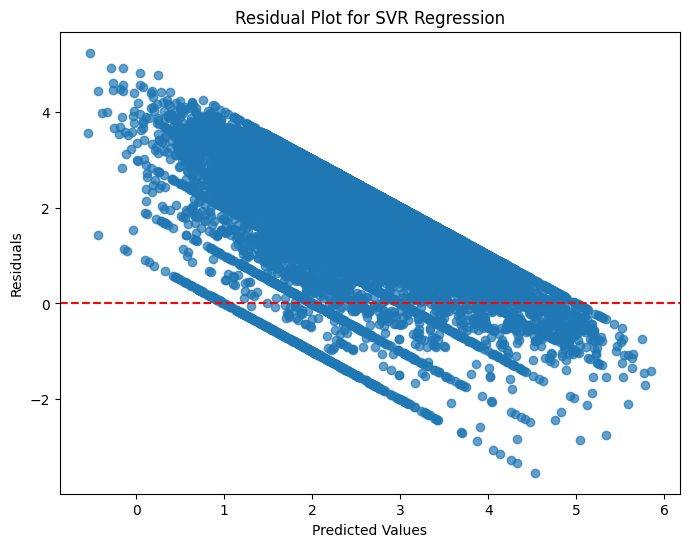

In [ ]:
# Plot residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_pred, y_reg_test - y_reg_pred, alpha=0.7)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot for SVR Regression')
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [ ]:
# SVM Classification Task
# Select numerical features for classification (excluding target)
classification_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
classification_features.remove(classification_target)

X_clf = df[classification_features]
y_clf = df[classification_target]

In [ ]:
# Split data
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# Standardize features
scaler_clf = StandardScaler()
X_clf_train = scaler_clf.fit_transform(X_clf_train)
X_clf_test = scaler_clf.transform(X_clf_test)


In [11]:
# Alternative model: Use Logistic Regression instead of SVC for compatibility
from sklearn.linear_model import LogisticRegression

svc = LogisticRegression(max_iter=1000)
svc.fit(X_clf_train, y_clf_train)

# Evaluate SVC model
y_clf_pred = svc.predict(X_clf_test)
accuracy = accuracy_score(y_clf_test, y_clf_pred)
print("SVC Classification Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_clf_test, y_clf_pred))


SVC Classification Accuracy: 0.8973011874775099
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      9918
           1       0.84      0.79      0.81      3977

    accuracy                           0.90     13895
   macro avg       0.88      0.87      0.87     13895
weighted avg       0.90      0.90      0.90     13895



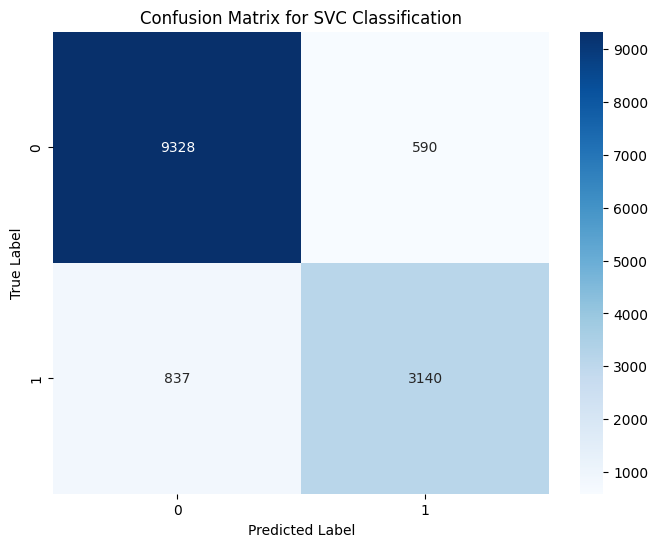

In [12]:
# Plot confusion matrix
cm = confusion_matrix(y_clf_test, y_clf_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVC Classification')
plt.show()